In [6]:
import pandas as pd
import numpy as np
import string

# Problem 2: a linguistic street map of Singapore

There is considerable linguistic variety in Singapore road names: Malaysians names (Jalan Besar), British names (Northumberland road), Chinese names (Keong Saik Road), Indian names (Veerasamy road), Jewish names (Belilios road), and the usual generic sorts of names that describe either area landmarks or other common noun.

![Image](streets.png)

In [2]:
# load the dataset
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/streets.csv'
street_names = pd.read_csv(url)
street_names.head(10)

,name,tag,origin
0,Saiboo,Street,Indian
1,Merchant,Loop,Generic
2,Hill,Street,Generic
3,Ophir,Road,Malay
4,Buona,Vista Road,Other
5,Sengkang,Avenue,Chinese
6,Ang Mo Kio,Avenue,Chinese
7,Brickland,Road,British
8,Choa Chu Kang,Road,Chinese
9,Woodlands,Avenue,Generic


**``Origin`` column values:**

- Chinese (all dialects including Cantonese, Hokkien, Mandarin, etc)
- Malay
- Indian (all languages of the subcontinent)
- British
- Generic (Race Course Road, Sunrise Place, etc)
- Other (Other languages).

In [3]:
street_names.origin.value_counts()

Malay      927
British    798
Generic    497
Chinese    403
Other      167
Indian      42
Name: origin, dtype: int64

The **goal** is to predict the ``origin`` column from the ``street`` and ``tag`` columns.

**Part 1:** Add the following features:

- Number of words in road name (more words => more likely to be Chinese.) Assign it to a column named `n_words`.
- Average word length in road name (longer words => more likely to be British or Indian.) Assign it to a column named `avg_word_len`.
- Is the road tag Malay? (if yes => very correlated with being Malay.) **Malay tags**: *Jalan*, *Lorong*, *Bukit*, *Lengkok*, *Taman*, *Kampong*, *Lengkong*. Assign it to a column named `is_malay`.

In [47]:
malay_tags = ['Jalan', 'Lorong', 'Bukit', 'Lengkok', 'Taman', 'Kampong', 'Lengkong'] 

In [50]:
street_names['is_malay'] = street_names.tag.isin(malay_tags)

In [51]:
street_names['is_malay'][street_names['is_malay']==True] = 1
street_names['is_malay'][street_names['is_malay']==False] = 0

street_names['is_malay'].value_counts()

/var/folders/kn/55jn3px126z8xdxt60nbxw5h0000gn/T/ipykernel_17351/1867319711.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  street_names['is_malay'][street_names['is_malay']==True] = 1


0.0    2367
1.0     467
Name: is_malay, dtype: int64

In [36]:
street_names['word_avg'] = street_names.name

In [37]:
for i in range(len(street_names.name)):
    street_names.word_avg[i] = street_names.name[i].split(" ")
    
street_names['word_avg']

0            [Saiboo]
1          [Merchant]
2              [Hill]
3             [Ophir]
4             [Buona]
            ...      
2829       [Florence]
2830     [Hoot, Kiam]
2831         [Clarke]
2832    [Countryside]
2833          [Nepal]
Name: word_avg, Length: 2834, dtype: object

In [44]:
street_names['word_count'] = street_names.word_avg.apply(len)

In [45]:
street_names['word_count']

0       1
1       1
2       1
3       1
4       1
       ..
2829    1
2830    2
2831    1
2832    1
2833    1
Name: word_count, Length: 2834, dtype: int64

In [46]:
street_names['word_avg'] = street_names.name.apply(len)/street_names['word_count']

street_names['word_avg']

0        6.0
1        8.0
2        4.0
3        5.0
4        5.0
        ... 
2829     8.0
2830     4.5
2831     6.0
2832    11.0
2833     5.0
Name: word_avg, Length: 2834, dtype: float64

**Part 2:** define the matrix X (columns `name`, `n_words`, `avg_word_len`, `is_malay`) and the target vector y (column `origin`)

In [54]:
X = street_names[['name', 'word_count', 'word_avg', 'is_malay']]

y = street_names.origin

**Part 3:** split X and y into training and testing sets.

In [57]:


# train/test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y)



**Part 4:** build a classification pipeline.

The pipeline must use `CountVectorizer` to compute the number of **character 1-gram, 2-grams, 3-grams and 4-grams** from the column `name` ([CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html#sklearn.feature_extraction.text.CountVectorizer) has an `analyzer` parameter that you'll have to set to `analyzer='char'`.)

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

In [73]:
feature_processor = ColumnTransformer(transformers=[
    ('vect',CountVectorizer(analyzer='char', ngram_range = (1,4)),'name'),
],remainder='passthrough')

In [74]:


pipe = Pipeline(steps=[
    ('proc', feature_processor), 
    ('clf', MultinomialNB()) 
])

pipe

Pipeline(steps=[('proc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('vect',
                                                  CountVectorizer(analyzer='char',
                                                                  ngram_range=(1,
                                                                               4)),
                                                  'name')])),
                ('clf', MultinomialNB())])

**Part 5:** Fit the classification pipeline to the training data, and  evaluate its performance on the testing set.

In [75]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('proc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('vect',
                                                  CountVectorizer(analyzer='char',
                                                                  ngram_range=(1,
                                                                               4)),
                                                  'name')])),
                ('clf', MultinomialNB())])

In [76]:
y_test_pred = pipe.predict(X_test)

In [82]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [80]:
accuracy_score(y_test,y_test_pred)

0.843441466854725

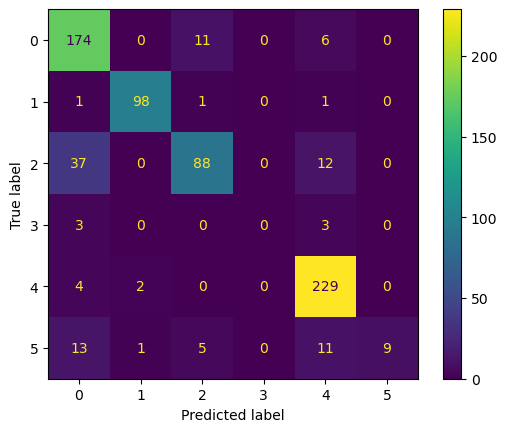

In [84]:
cm = confusion_matrix(y_test,y_test_pred)

ConfusionMatrixDisplay(cm).plot()

The model predicts street names with 84% accuracy, which seems pretty good. I'll note that it does a poorer job of classifying the less frequent labels.